---
title: Multivariate Statistics
subtitle: Foundations of Statistical Analysis in Python
abstract: This notebook explores multivariate relationships through linear regression analysis, highlighting its strengths and limitations. Practical examples and visualizations are provided to help users understand and apply these statistical concepts effectively.
author:
  - name: Karol Flisikowski
    affiliations: 
      - Gdansk University of Technology
      - Chongqing Technology and Business University
    orcid: 0000-0002-4160-1297
    email: karol@ctbu.edu.cn
date: 2025-05-25
---

## Goals of this lecture

There are many ways to *describe* a distribution. 

Here we will discuss:
- Measurement of the relationship between distributions using **linear, regression analysis**.

## Importing relevant libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns ### importing seaborn
import pandas as pd
import scipy.stats as ss

In [2]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

In [3]:
df_estate = pd.read_csv("data/models/real_estate.csv")
df_estate.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'data/models/real_estate.csv'

## Describing *multivariate* data with regression models

- So far, we've been focusing on *univariate and bivariate data*: analysis.
- What if we want to describe how *two or more than two distributions* relate to each other?

1. Let's simplify variables' names:

In [ ]:
df_estate = df_estate.rename(columns={
    'house age': 'house_age_years',
    'house price of unit area': 'price_twd_msq',
    'number of convenience stores': 'n_convenience',
    'distance to the nearest MRT station': 'dist_to_mrt_m'
})

df_estate.head(5)

,No,house_age_years,dist_to_mrt_m,n_convenience,latitude,longitude,price_twd_msq
0,1,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,5.0,390.56840,5,24.97937,121.54245,43.1


We can also perform binning for "house_age_years":

In [ ]:
df_estate['house_age_cat'] = pd.cut(
    df_estate['house_age_years'],
    bins=[0, 15, 30, 45],
    include_lowest=True,
    right=False
)
df_estate.head(5)

,No,house_age_years,dist_to_mrt_m,n_convenience,latitude,longitude,price_twd_msq,house_age_cat
0,1,32.0,84.87882,10,24.98298,121.54024,37.9,"[30, 45)"
1,2,19.5,306.59470,9,24.98034,121.53951,42.2,"[15, 30)"
2,3,13.3,561.98450,5,24.98746,121.54391,47.3,"[0, 15)"
3,4,13.3,561.98450,5,24.98746,121.54391,54.8,"[0, 15)"
4,5,5.0,390.56840,5,24.97937,121.54245,43.1,"[0, 15)"


In [ ]:
cat_dict = {
    pd.Interval(left=0, right=15, closed='left'): '0-15',
    pd.Interval(left=15, right=30, closed='left'): '15-30',
    pd.Interval(left=30, right=45, closed='left'): '30-45'
}

df_estate['house_age_cat_str'] = df_estate['house_age_cat'].map(cat_dict)
df_estate['house_age_cat_str'] = df_estate['house_age_cat_str'].astype('category')
df_estate.head()

,No,house_age_years,dist_to_mrt_m,n_convenience,latitude,longitude,price_twd_msq,house_age_cat,house_age_cat_str
0,1,32.0,84.87882,10,24.98298,121.54024,37.9,"[30, 45)",30-45
1,2,19.5,306.59470,9,24.98034,121.53951,42.2,"[15, 30)",15-30
2,3,13.3,561.98450,5,24.98746,121.54391,47.3,"[0, 15)",0-15
3,4,13.3,561.98450,5,24.98746,121.54391,54.8,"[0, 15)",0-15
4,5,5.0,390.56840,5,24.97937,121.54245,43.1,"[0, 15)",0-15


In [ ]:
#Checking the updated datatype of house_age_years
df_estate.house_age_cat_str.dtype

CategoricalDtype(categories=['0-15', '15-30', '30-45'], ordered=True, categories_dtype=str)

In [ ]:
#Checking the dataframe for any NA values
df_estate.isna().any()

No                   False
house_age_years      False
dist_to_mrt_m        False
n_convenience        False
latitude             False
longitude            False
price_twd_msq        False
house_age_cat        False
house_age_cat_str    False
dtype: bool

## Descriptive Statistics

Prepare a heatmap with correlation coefficients on it:

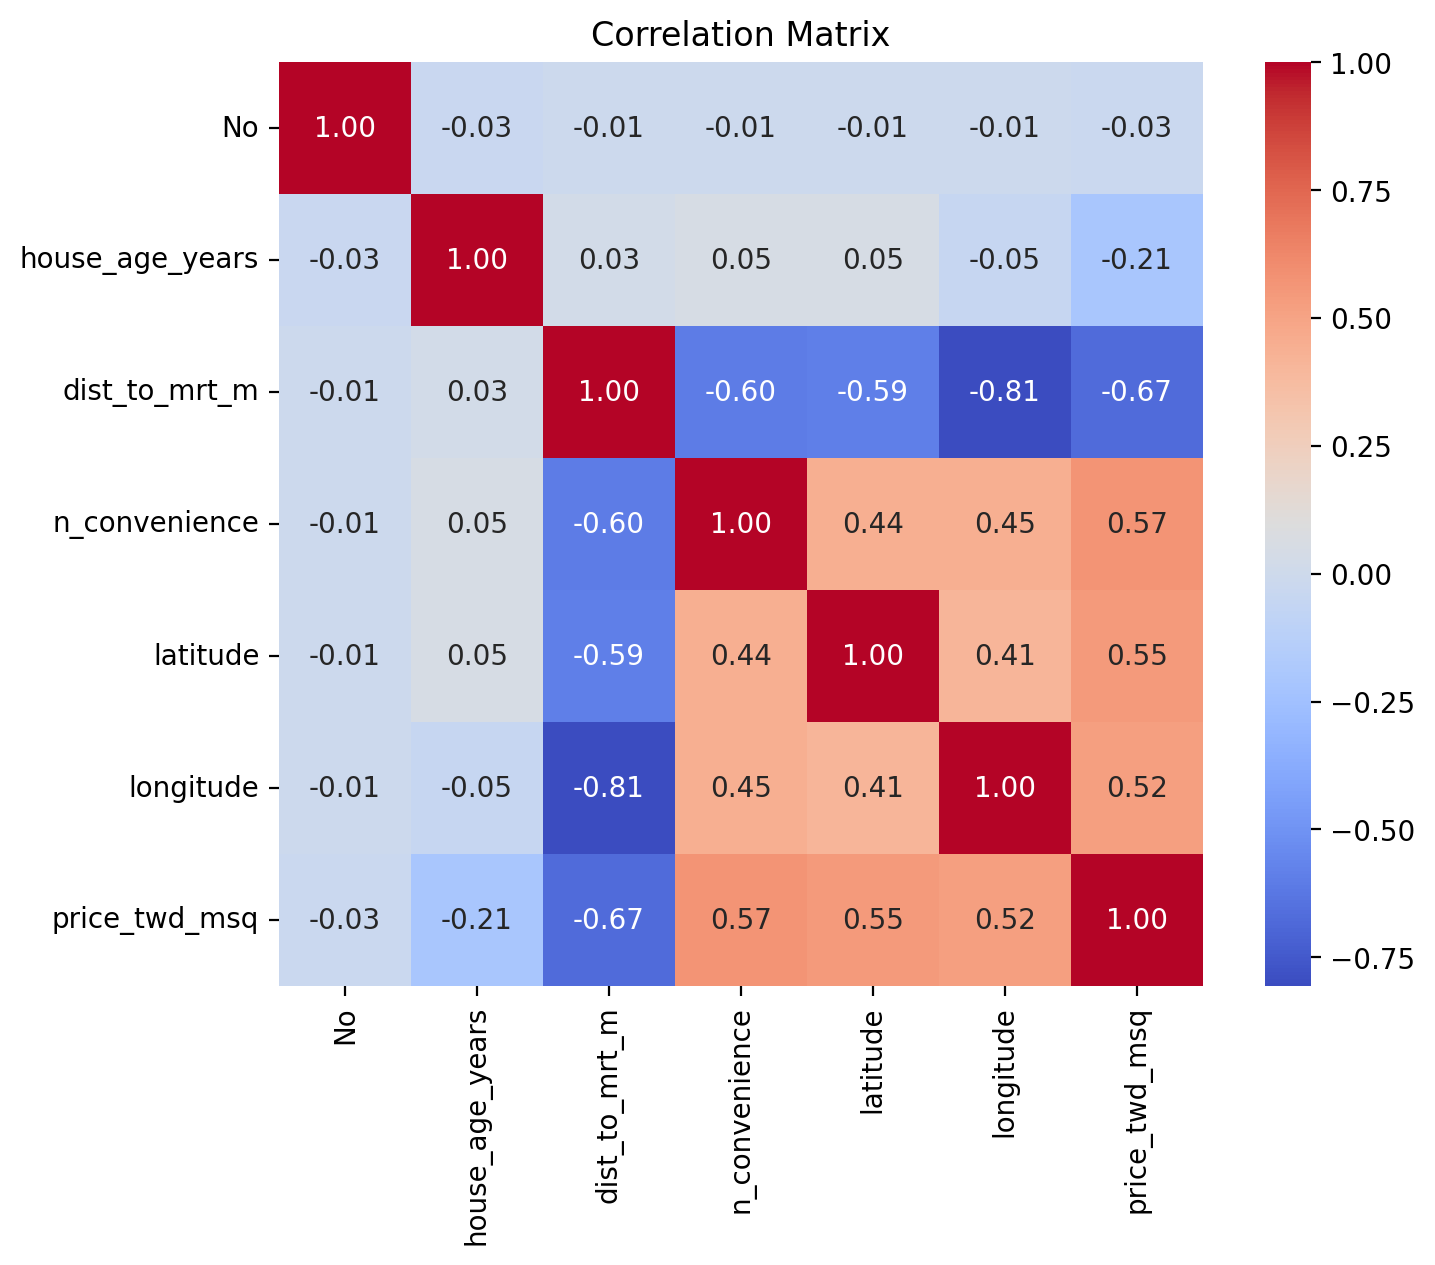

In [ ]:
corr_matrix = df_estate.iloc[:, :7].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

Strong negative correlation between longitude and distance to MRT; which suggests that most of the MRT it located in higher longitudes in the city.

Also an observable negative correlation between distance to MRT and price; which is quite self-explanatory - the flats closer to the MRT are much more expensive.

Draw a scatter plot of n_convenience vs. price_twd_msq:

<Axes: xlabel='price_twd_msq', ylabel='n_convenience'>

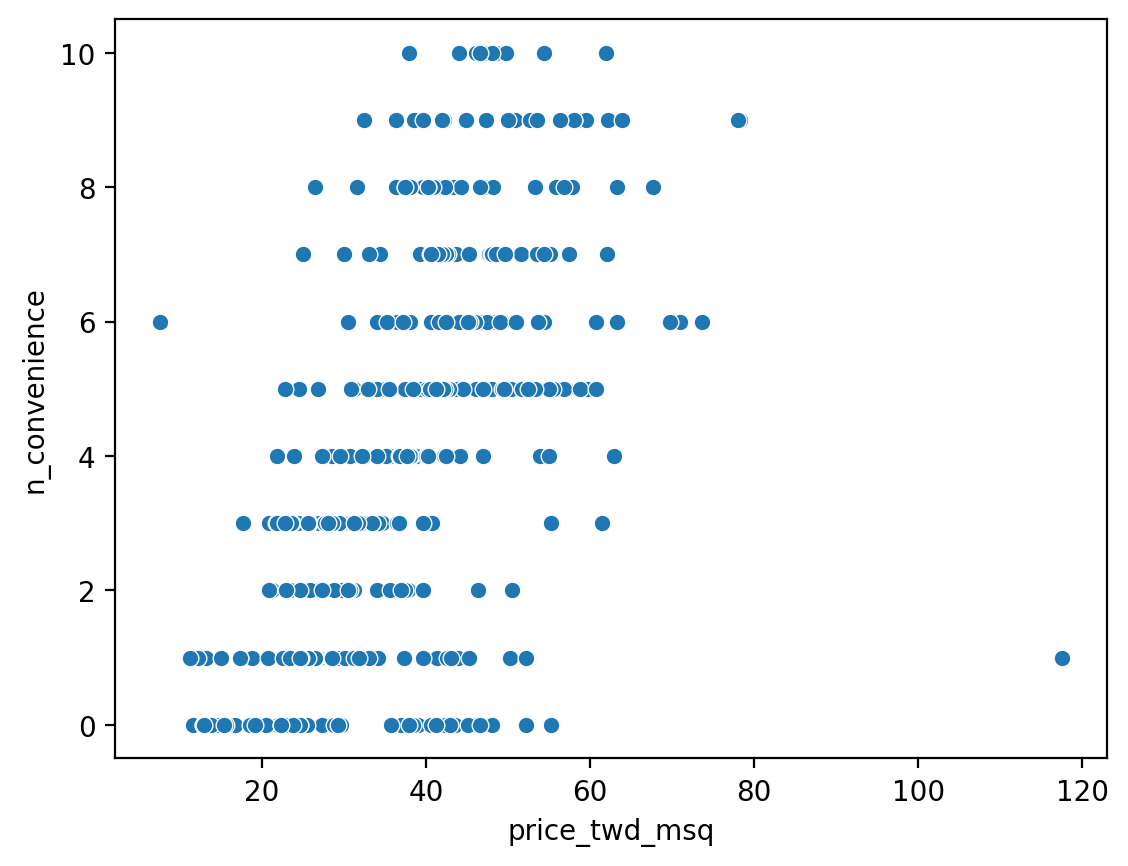

In [ ]:
sns.scatterplot(data=df_estate, x="price_twd_msq", y="n_convenience")

# mildly strong positive correlation can be observed between these two

Draw a scatter plot of house_age_years vs. price_twd_msq:

<Axes: xlabel='house_age_years', ylabel='price_twd_msq'>

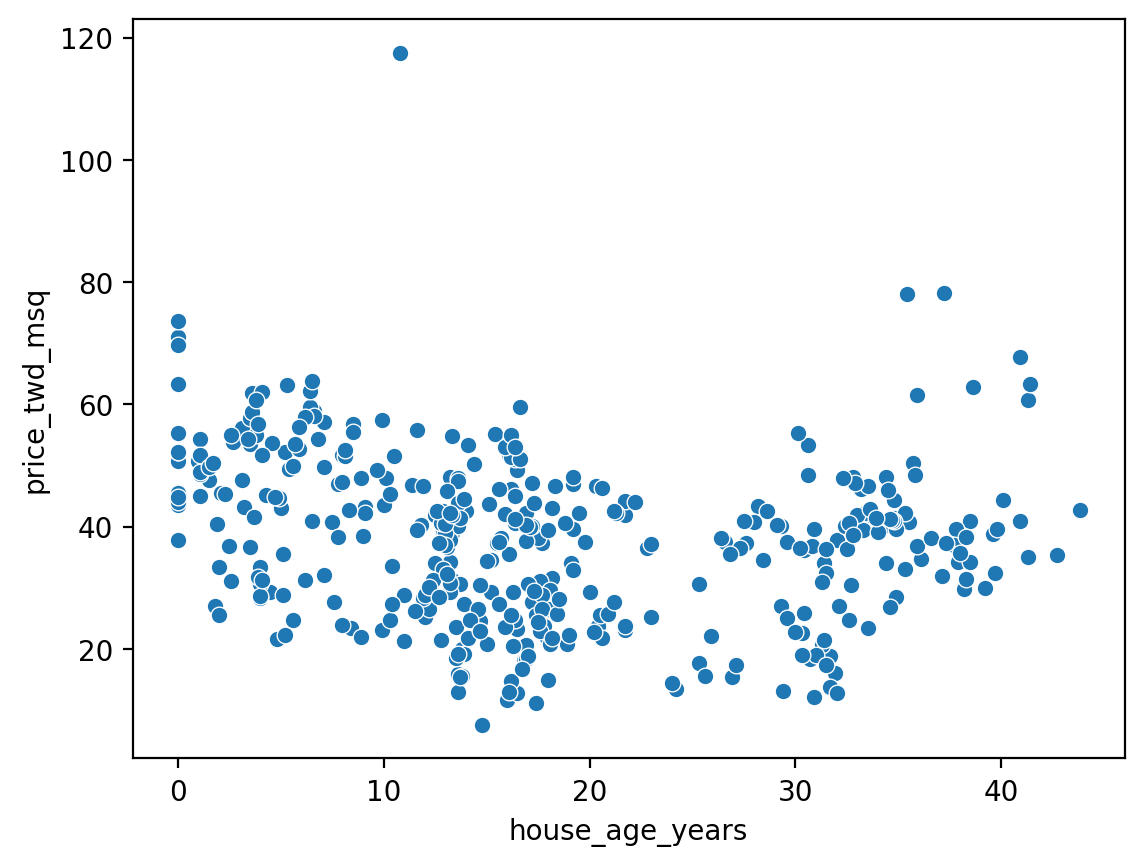

In [ ]:
sns.scatterplot(data=df_estate, x="house_age_years", y="price_twd_msq")

# really weak to no correlation, which is also supported by the heatmap (-0.21)

Draw a scatter plot of distance to nearest MRT station vs. price_twd_msq:

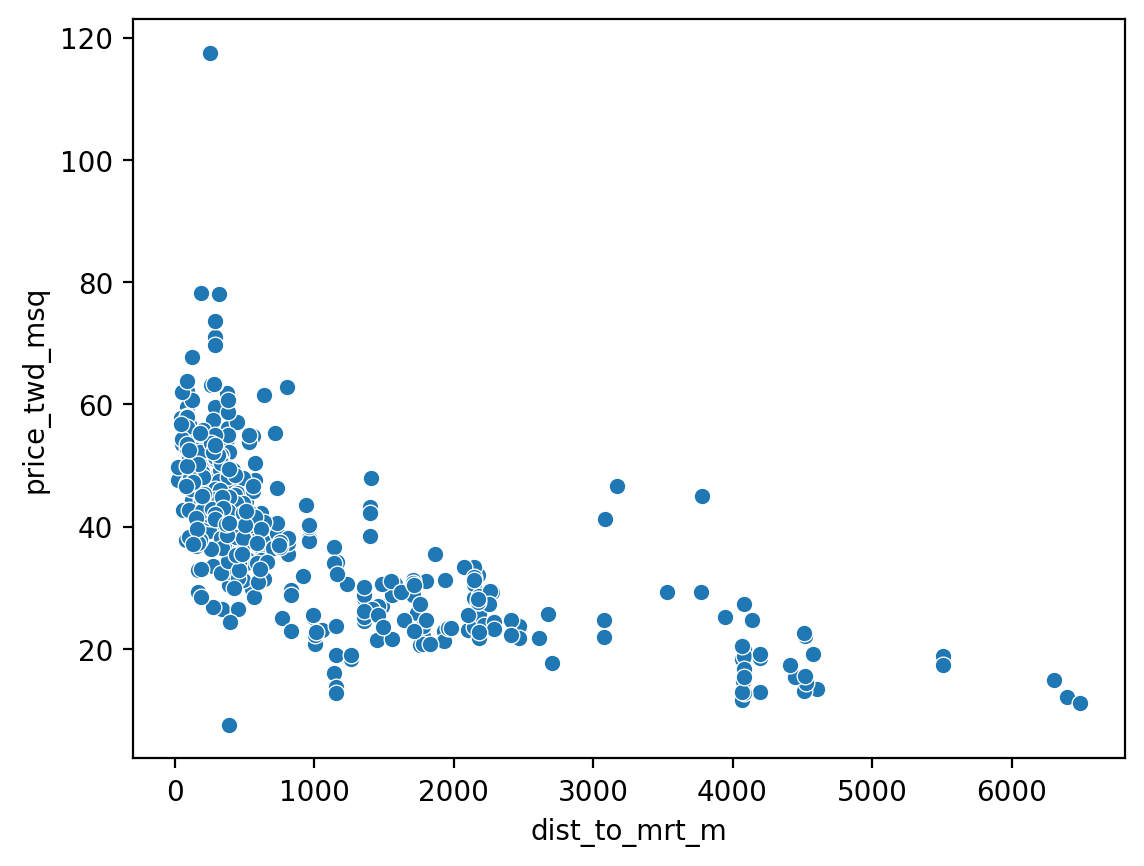

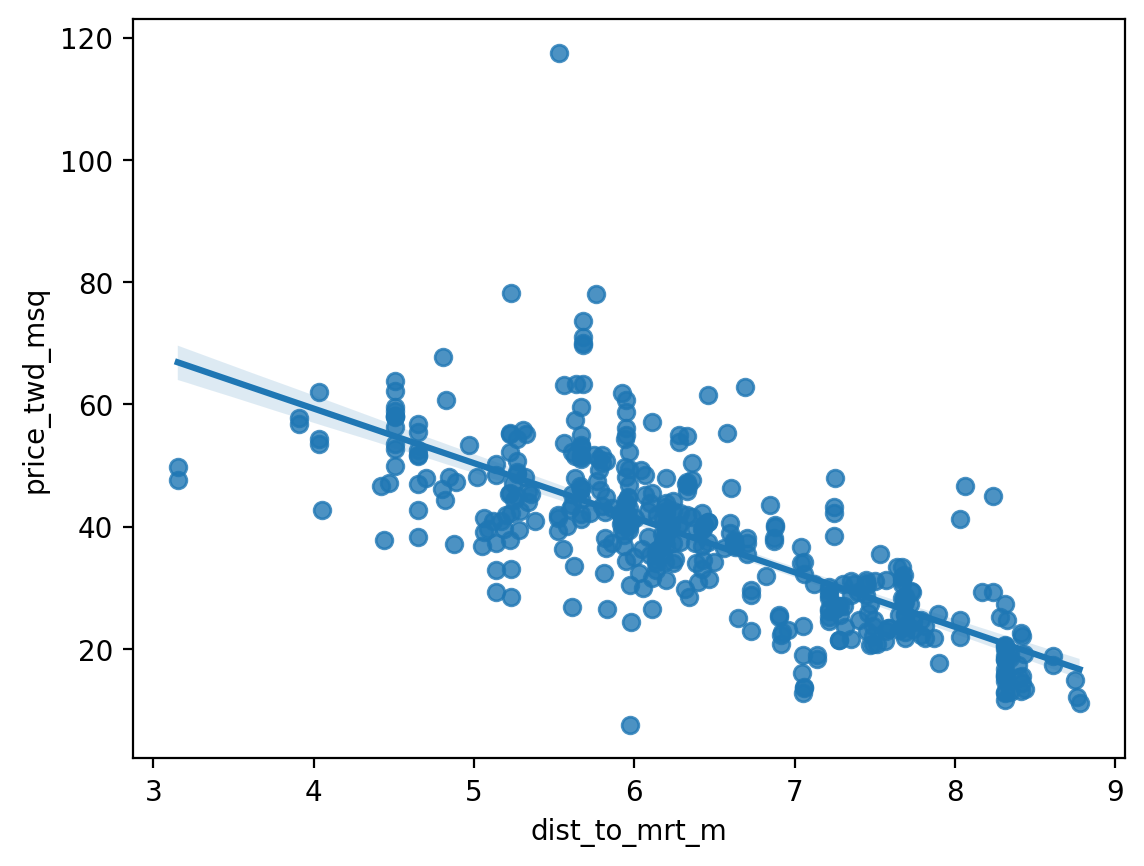

In [ ]:
sns.scatterplot(data=df_estate, x="dist_to_mrt_m", y="price_twd_msq")
plt.show()

dist_to_mrt_log = np.log(df_estate['dist_to_mrt_m'])

sns.regplot(data=df_estate, x=dist_to_mrt_log, y="price_twd_msq")
plt.show()

Plot a histogram of price_twd_msq with 10 bins, facet the plot so each house age group gets its own panel:

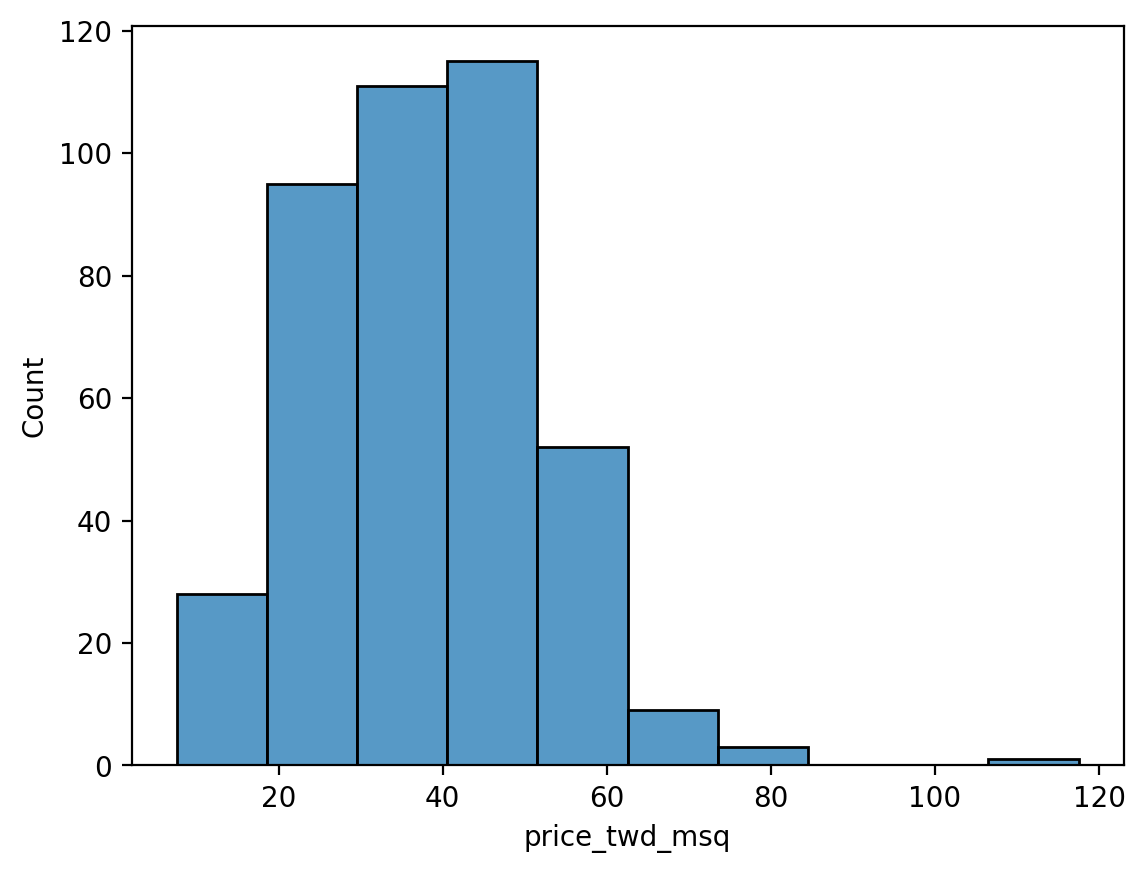

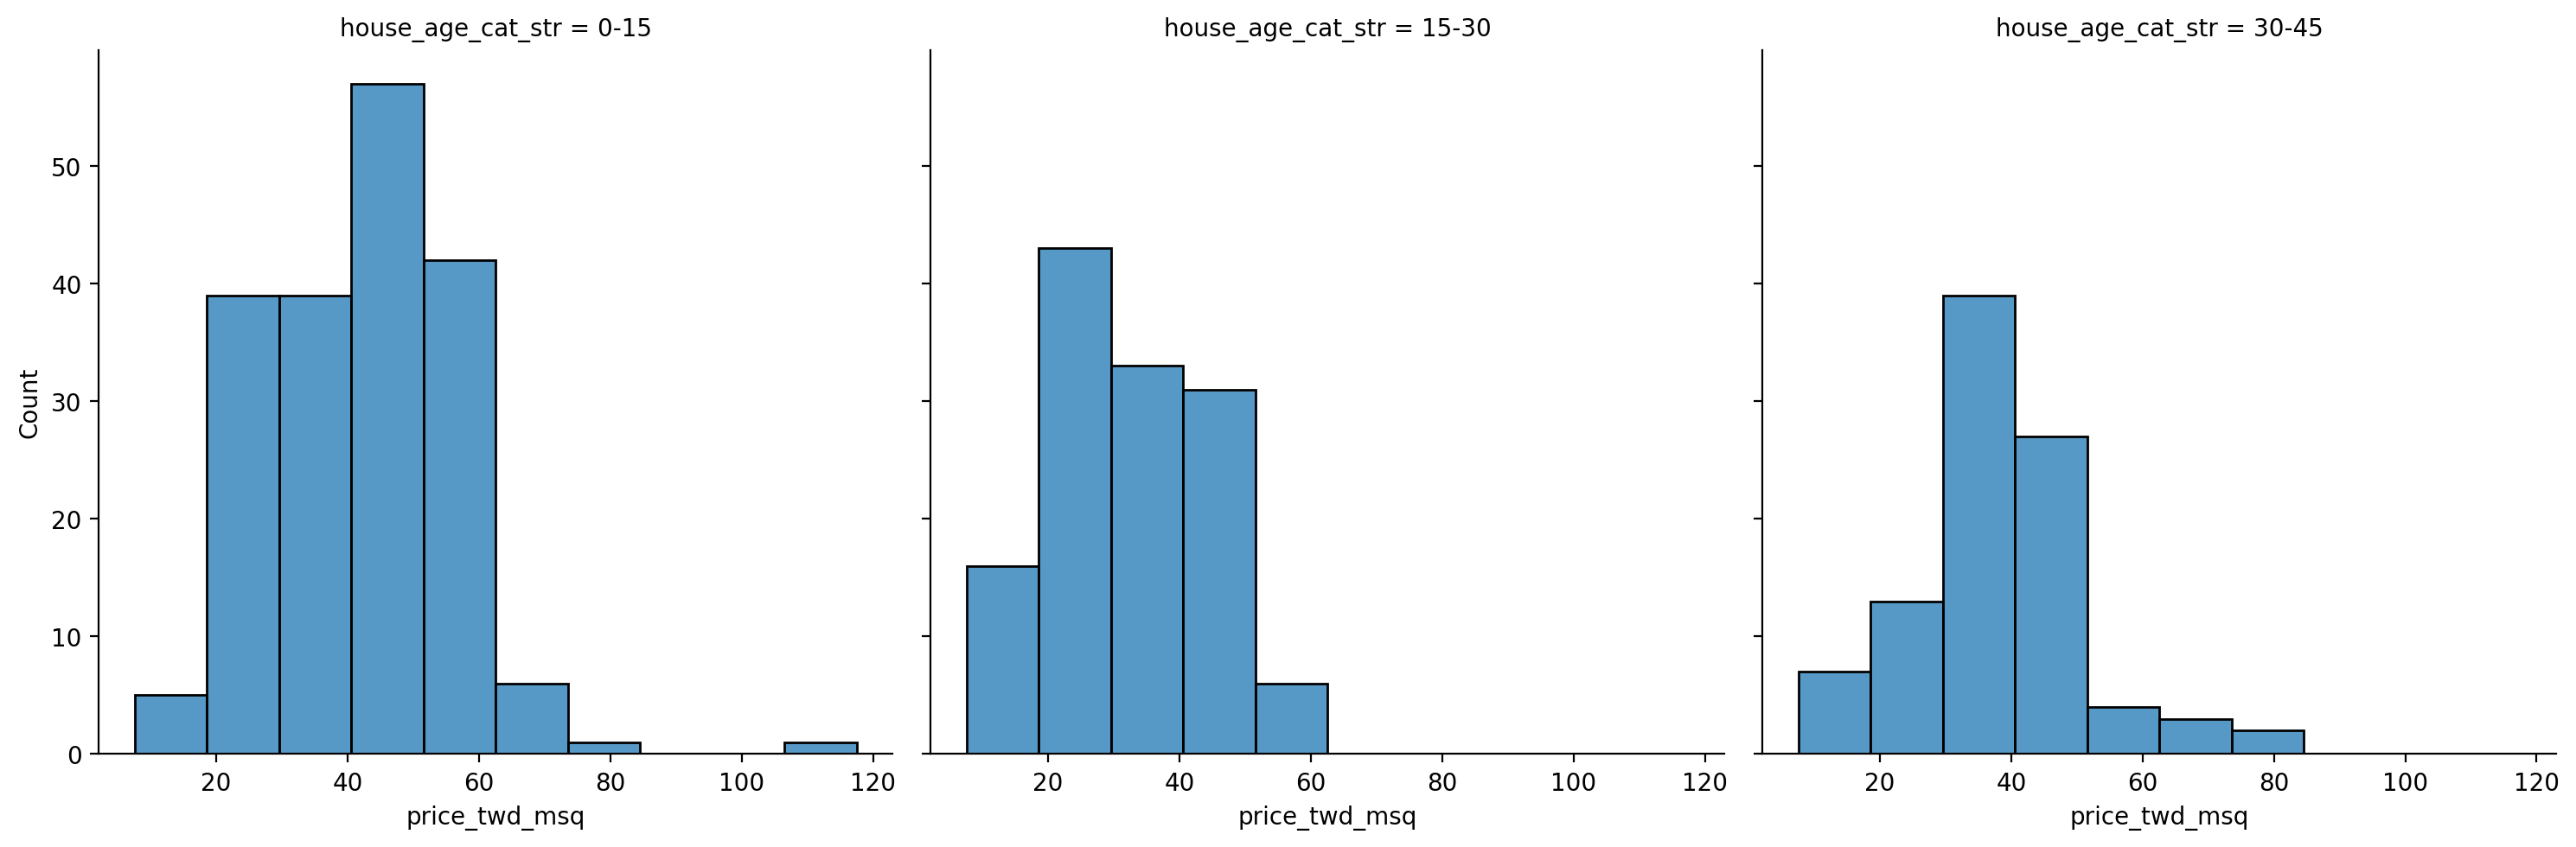

In [ ]:
sns.histplot(data=df_estate, x="price_twd_msq", bins=10)

sns.displot(data=df_estate, x="price_twd_msq", bins=10, col="house_age_cat_str")

Very long tails can be observed, as well as strong right-skewness

Summarize to calculate the mean, sd, median etc. house price/area by house age:

In [ ]:
df_estate.groupby("house_age_cat_str")["price_twd_msq"].agg(
    mean="mean",
    sd="std",
    median="median",
    min="min",
    max="max",
    count="count"
)

,mean,sd,median,min,max,count
house_age_cat_str,,,,,,
0-15,41.766842,14.164308,42.55,7.6,117.5,190
15-30,32.642636,11.398217,32.90,11.2,59.6,129
30-45,37.654737,12.842547,38.30,12.2,78.3,95


## Simple model

Run a linear regression of price_twd_msq vs. best, but only 1 predictor:

In [ ]:
import statsmodels.api as sm

# Let's use 'dist_to_mrt_m' as the single best predictor
X = df_estate[['dist_to_mrt_m']]
y = df_estate['price_twd_msq']

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
model1 = sm.OLS(y, X).fit()

# Show the summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          price_twd_msq   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     342.2
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           4.64e-56
Time:                        23:53:42   Log-Likelihood:                -1542.5
No. Observations:                 414   AIC:                             3089.
Df Residuals:                     412   BIC:                             3097.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            45.8514      0.653     70.258

What do the above results mean? Write down the model and interpret it.

Discuss model accuracy.

Kurtosis 10.135 means very long tails

R-squared 0.454 is quite low, as much as 60% of dependency is not explained

skewness 1.2 is strongly right skewed, this is explained by the very long tail

Durbin-Watson of 2.151 means lack of autocorrelation

## Model diagnostics

### 4 Diagnostic plots

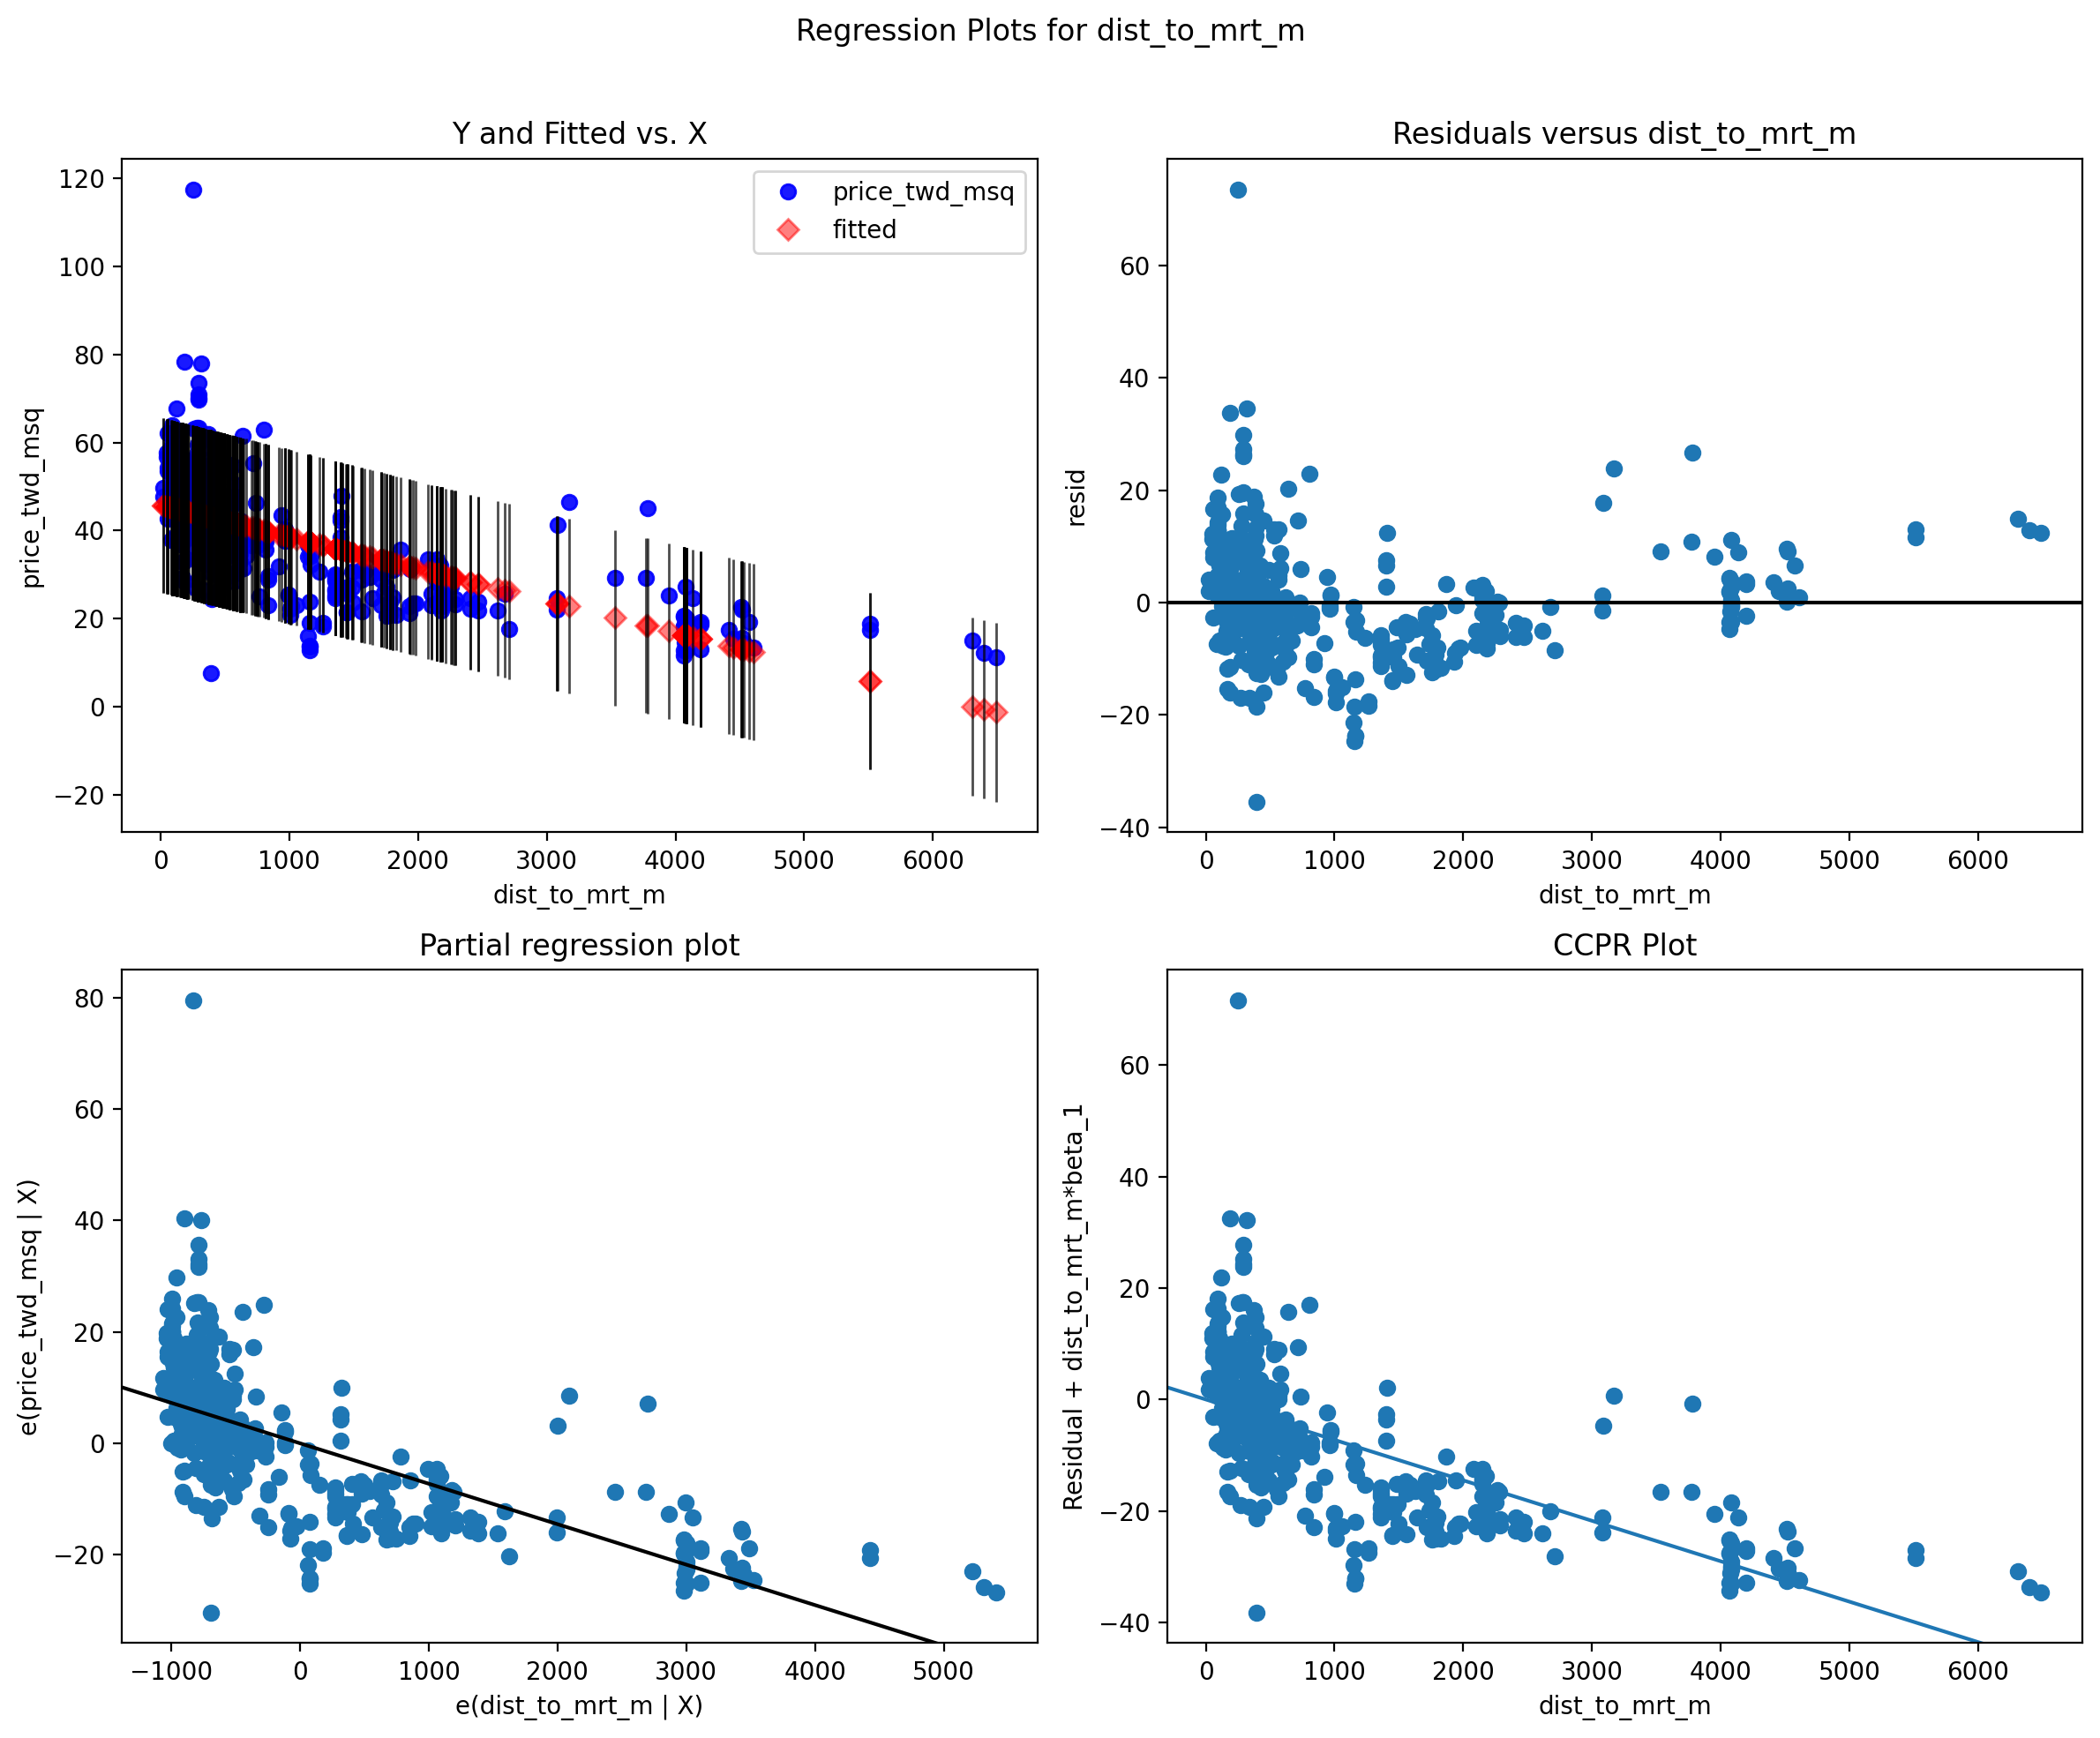

In [ ]:
fig = plt.figure(figsize=(12, 10))
sm.graphics.plot_regress_exog(model1, 'dist_to_mrt_m', fig=fig)
plt.show()

The Y and fitted vs. X plot shows that housing prices tend to decrease as the distance to MRT station increases, which is a clear negative correlation.

The Residuals plot shows that the relationship is not exactly linear, and it does have some unequal variance - heteroskedasticity.

The Partial Regression plot confirms that the distance to MRT has a strong negative effect on housing prices.

Last but not least, the CCPR plot confirms the importance of the predictor while also suggesting that the relationship is not perfectly linear.

### Outliers and high levarage points:

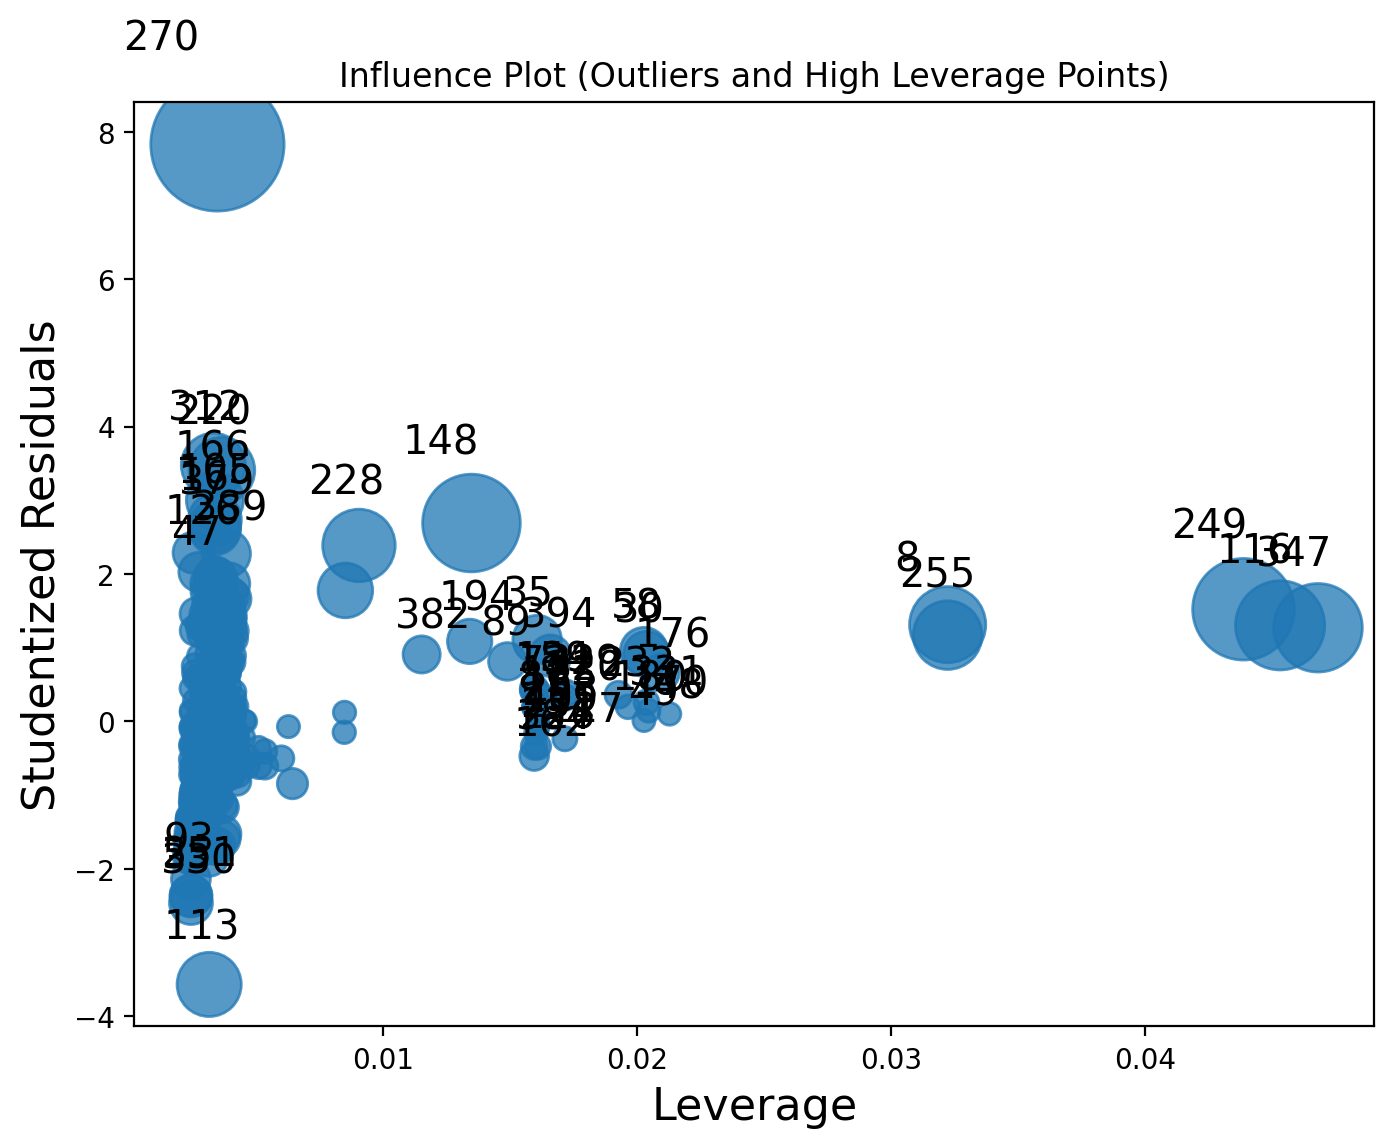

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.influence_plot(model1, ax=ax, criterion="cooks")
plt.title("Influence Plot (Outliers and High Leverage Points)")
plt.show()

Discussion:

The plot shows which data points might be unusual or strongly affecting the regression model.

Especially the point 270 stands out the most because it has a very high residual and a big influence bubble, so it could be pulling the model quite a lot. A few points on the right also have high leverage, meaning they are unusual compared to the rest of the data, and yhe model does seem to be influenced by these outliers.


## Multiple Regression Model

### Test and training set 

We begin by splitting the dataset into two parts, training set and testing set. In this example we will randomly take 75% row in this dataset and put it into the training set, and other 25% row in the testing set:

In [ ]:
# One-hot encoding for house_age_cat_str in df_estate

encode_dict = {True: 1, False: 0}

house_age_0_15 = df_estate['house_age_cat_str'] == '0-15'
house_age_15_30 = df_estate['house_age_cat_str'] == '15-30'
house_age_30_45 = df_estate['house_age_cat_str'] == '30-45'

df_estate['house_age_0_15'] = house_age_0_15.map(encode_dict)
df_estate['house_age_15_30'] = house_age_15_30.map(encode_dict)
df_estate['house_age_30_45'] = house_age_30_45.map(encode_dict)

df_estate.head()

,No,house_age_years,dist_to_mrt_m,n_convenience,latitude,longitude,price_twd_msq,house_age_cat,house_age_cat_str,house_age_0_15,house_age_15_30,house_age_30_45
0,1,32.0,84.87882,10,24.98298,121.54024,37.9,"[30, 45)",30-45,0,0,1
1,2,19.5,306.59470,9,24.98034,121.53951,42.2,"[15, 30)",15-30,0,1,0
2,3,13.3,561.98450,5,24.98746,121.54391,47.3,"[0, 15)",0-15,1,0,0
3,4,13.3,561.98450,5,24.98746,121.54391,54.8,"[0, 15)",0-15,1,0,0
4,5,5.0,390.56840,5,24.97937,121.54245,43.1,"[0, 15)",0-15,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split

# 75% training, 25% testing, random_state=12 for reproducibility
train, test = train_test_split(df_estate, train_size=0.75, random_state=12)

Now we have our training set and testing set. 

### Variable selection methods

Generally, selecting variables for linear regression is a debatable topic.

There are many methods for variable selecting, namely, forward stepwise selection, backward stepwise selection, etc, some are valid, some are heavily criticized.

I recommend this document: <https://www.stat.cmu.edu/~cshalizi/mreg/15/lectures/26/lecture-26.pdf> and Gung's comment: <https://stats.stackexchange.com/questions/20836/algorithms-for-automatic-model-selection/20856#20856> if you want to learn more about variable selection process.

[**If our goal is prediction**]{.ul}, it is safer to include all predictors in our model, removing variables without knowing the science behind it usually does more harm than good!!!

We begin to create our multiple linear regression model:

In [ ]:
import statsmodels.formula.api as smf
model2 = smf.ols('price_twd_msq ~ dist_to_mrt_m + house_age_0_15 + house_age_30_45', data = df_estate)
result2 = model2.fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_twd_msq   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     128.9
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           7.84e-59
Time:                        23:53:43   Log-Likelihood:                -1530.2
No. Observations:                 414   AIC:                             3068.
Df Residuals:                     410   BIC:                             3084.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          43.4096      1.052     41.275      0.000      41.342      45.477
dist_to_mrt_m      -0.0070      0.000    -17.889      0.000      -0.008      -0.006
house_age_0_15      4.8450      1.143      4.239      0.000       2.598       7.092
house_age_30_45    -0.1016      1.355     -0.075      0.940      -2.765       2.562
==============================================================================
Omnibus:                      145.540   Durbin-Watson:                   2.124
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1077.318
Skew:                           1.296   Prob(JB):                    1.16e-234
Kurtosis:                      10.466   Cond. No.                     6.17e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.17e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

What about distance to mrt? Please plot its scatterplot with the dependent variable and verify, if any transformation is needed:

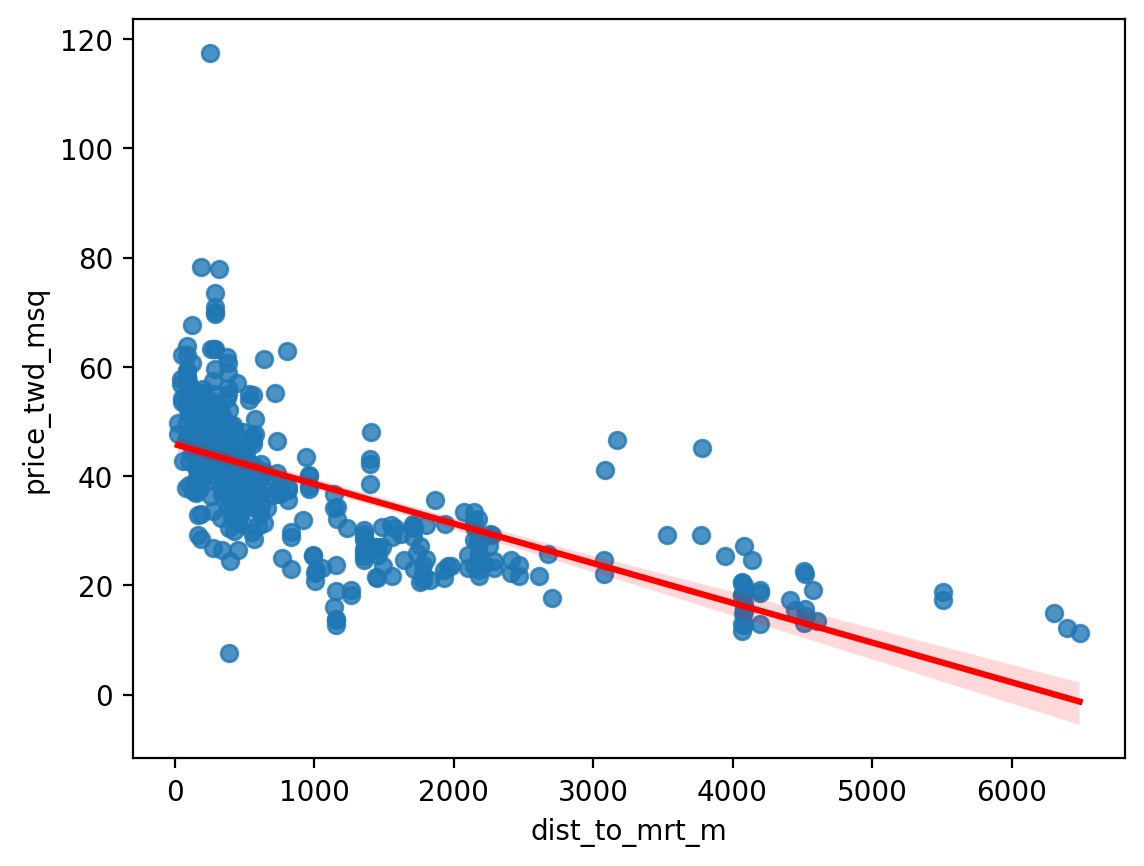

In [ ]:
sns.regplot(
    data=df_estate,
    x='dist_to_mrt_m',
    y='price_twd_msq',
    line_kws={'color': 'red'}
)

plt.show()

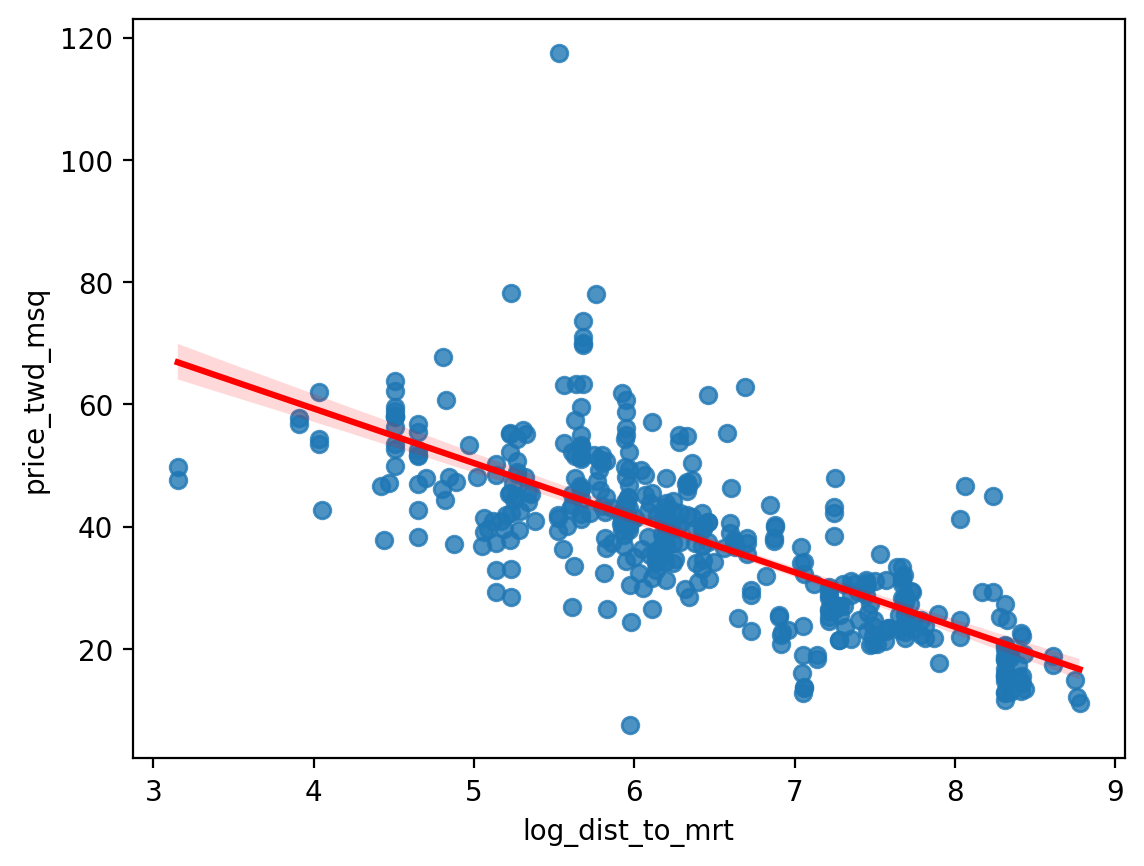

In [ ]:
df_estate['log_dist_to_mrt'] = np.log(df_estate['dist_to_mrt_m'])

sns.regplot(
    data=df_estate,
    x='log_dist_to_mrt',
    y='price_twd_msq',
    line_kws={'color': 'red'}
)

plt.show()

The relation is not perfectly linear, on the untransformed plot it looks to be more exponential; therefore an appropriate transformation would be a logarithmic one.
After the transformation, the relationship seems a lot more linear.
Thus, the third model should use logarithmic scale for the distance.

In [ ]:
#Calculating residual standard error of Model1
mse_result1 = model1.mse_resid
rse_result1 = np.sqrt(mse_result1)
print('The residual standard error for the above model is:',np.round(mse_result1,3))

The residual standard error for the above model is: 101.375


In [ ]:
#Calculating residual standard error of Model2
mse_result2 = result2.mse_resid
rse_result2 = np.sqrt(mse_result2)
print('The residual standard error for the above model is:',np.round(rse_result2,3))

The residual standard error for the above model is: 9.796


Looking at model summary, we see that variables .... are insignificant, so let's estimate the model without those variables:

Judging the summary, the insignificant variable in this model would be the 'house_age_30_45', as its p-value is very high at 0.940. This means that the results are highly consistent with the null hypothesis and there is little to no statistical difference.

In [ ]:
# Estimate next model here

model3 = smf.ols(
    'price_twd_msq ~ log_dist_to_mrt + house_age_0_15',
    data=df_estate
)

result3 = model3.fit()
result3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_twd_msq   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     261.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           6.40e-74
Time:                        23:53:43   Log-Likelihood:                -1497.9
No. Observations:                 414   AIC:                             3002.
Df Residuals:                     411   BIC:                             3014.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          91.4396      2.708     33.763      0.000      86.116      96.764
log_dist_to_mrt    -8.6469      0.403    -21.467      0.000      -9.439      -7.855
house_age_0_15      3.9415      0.904      4.360      0.000       2.164       5.719
==============================================================================
Omnibus:                      180.226   Durbin-Watson:                   2.094
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1884.848
Skew:                           1.562   Prob(JB):                         0.00
Kurtosis:                      12.975   Cond. No.                         40.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

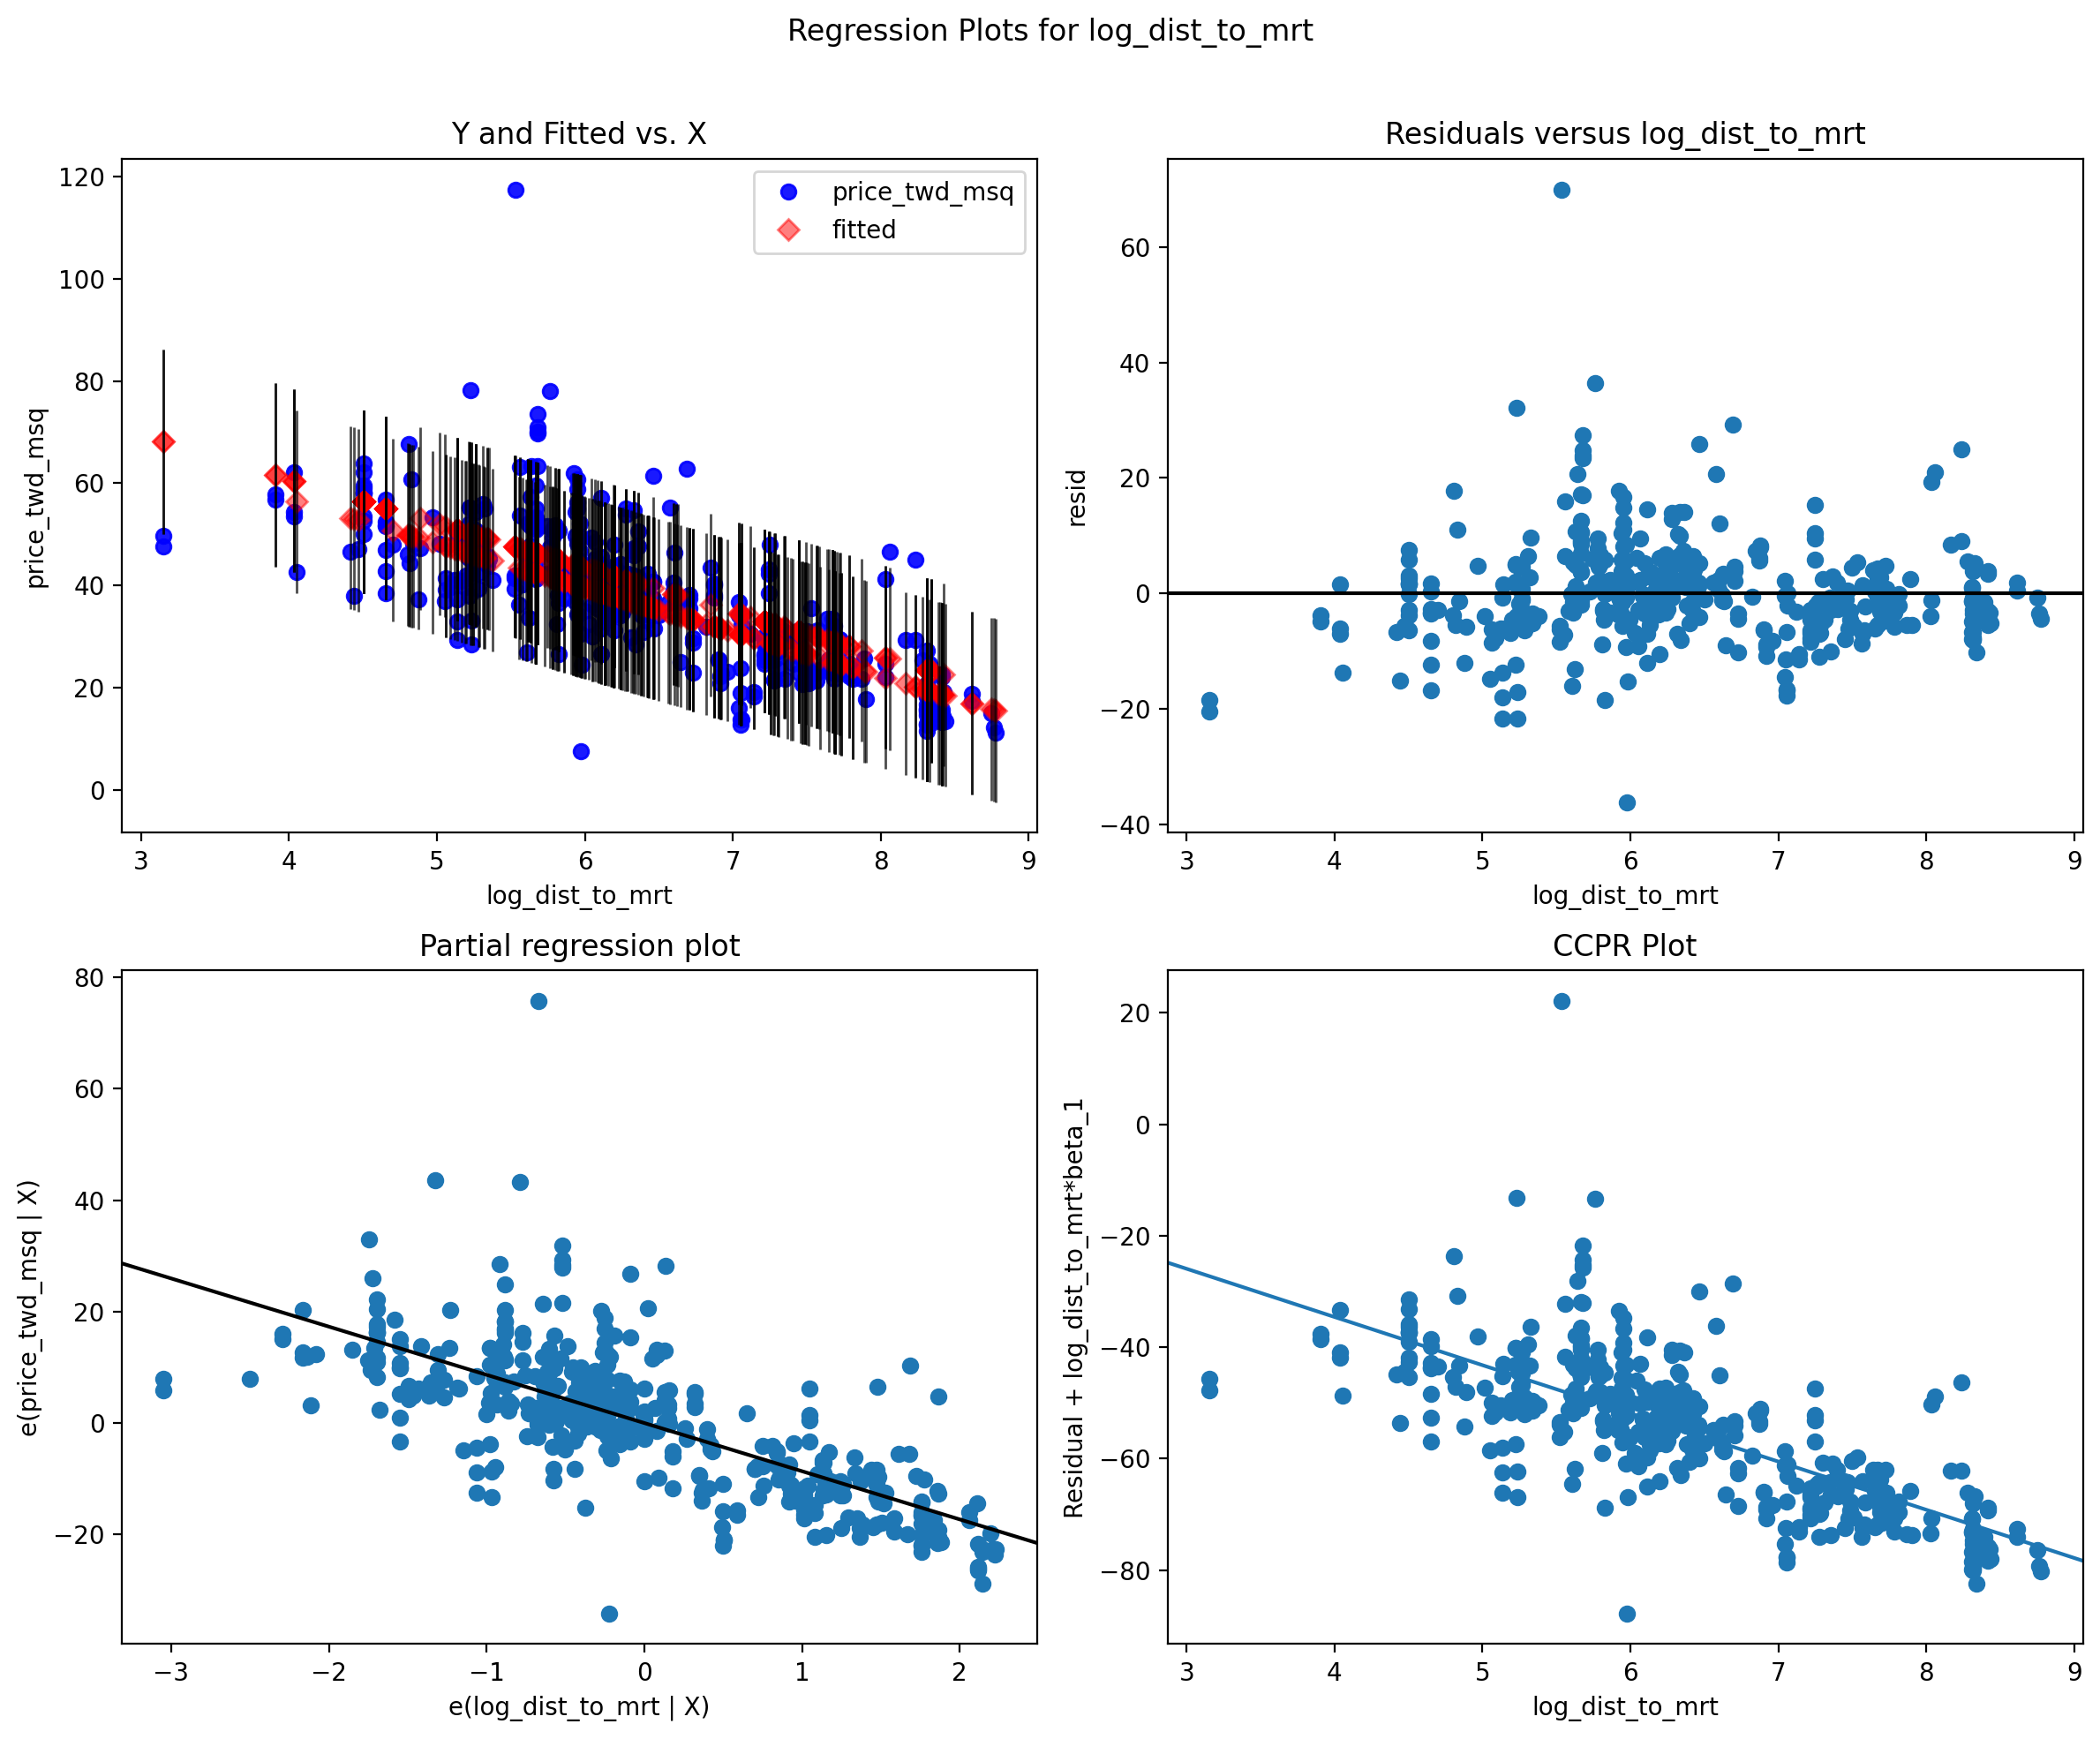

In [ ]:
fig = plt.figure(figsize=(12, 10))
sm.graphics.plot_regress_exog(result3, 'log_dist_to_mrt', fig=fig)
plt.show()

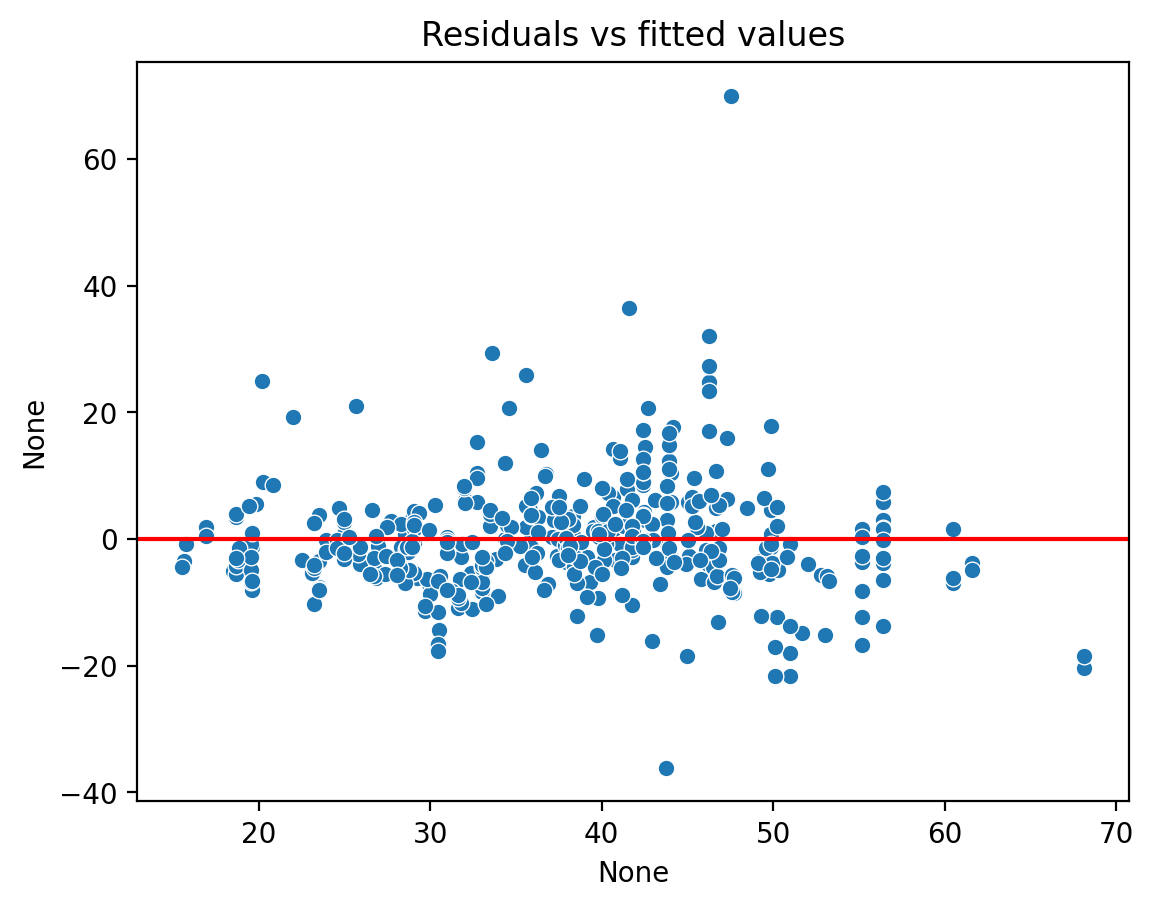

In [ ]:
fitted_values = result3.fittedvalues
residuals = result3.resid

sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red')
plt.title('Residuals vs fitted values')
plt.show()

In [ ]:
print("Model with unnecessary house_age_30_45;")
print("AIC:", result2.aic)
print("RSE:", np.sqrt(result2.mse_resid))

print("Model without this variable;")
print("AIC:", result3.aic)
print("RSE:", np.sqrt(result3.mse_resid))

Model with unnecessary house_age_30_45;
AIC: 3068.3179814418445
RSE: 9.795783944154879
Model without this variable;
AIC: 3001.8818082479575
RSE: 9.051337987627033


The reduced model has a bit lower AIC than the previous model, so it can be considered 'better' at least when it comes to ratio of fit to complexity.

### Evaluating multi-collinearity

There are many standards researchers apply for deciding whether a VIF is too large. In some domains, a VIF over 2 is worthy of suspicion. Others set the bar higher, at 5 or 10. Others still will say you shouldn't pay attention to these at all. Ultimately, the main thing to consider is that small effects are more likely to be "drowned out" by higher VIFs, but this may just be a natural, unavoidable fact with your model.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = df_estate[['dist_to_mrt_m', 'house_age_0_15', 'house_age_30_45']].copy()
X_vif = X_vif.fillna(0)  # Fill missing values if any

# Add constant (intercept)
X_vif = sm.add_constant(X_vif)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

           feature       VIF
0            const  4.772153
1    dist_to_mrt_m  1.061497
2   house_age_0_15  1.399276
3  house_age_30_45  1.400308


Discuss the results...

The VIF values are quite low. This means there is no serious multicollinearity problem between the predictors. VIF close to 1 means that the variable is almost not correlated with the other explanatory variables. The results shouldn't be skewed.



Finally we test our best model on test dataset (change, if any transformation on dist_to_mrt_m was needed):

In [ ]:
# Prepare test predictors for Model 3
from sklearn.metrics import mean_squared_error

# Model 3 uses log_dist_to_mrt, so create the same variable in the test set
test = test.copy()
test['log_dist_to_mrt'] = np.log(test['dist_to_mrt_m'])

# True values
y_test = test['price_twd_msq']

# Predict using Model 3
# Model 3 formula: price_twd_msq ~ log_dist_to_mrt + house_age_0_15
y_pred = result3.predict(test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE for Model 3: {rmse:.2f}")

Test RMSE for Model 3: 7.25


Interpret results...

This model predicts the test set housing prices with an average error of ~7.25 [price units] (1000 taiwanese dollars) per square meter, this suggests that the the model has reasonable predictive ability, although prediction errors still occur.


## Variable selection using best subset regression

*Best subset and stepwise (forward, backward, both) techniques of variable selection can be used to come up with the best linear regression model for the dependent variable medv.*

In [ ]:
# Best subset selection using sklearn's SequentialFeatureSelector (forward and backward)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

# Prepare predictors and target
X = df_estate[['dist_to_mrt_m', 'n_convenience', 'house_age_0_15', 'house_age_15_30', 'house_age_30_45']]
y = df_estate['price_twd_msq']

# Initialize linear regression model
lr = LinearRegression()

# Forward stepwise selection
sfs_forward = SequentialFeatureSelector(lr, n_features_to_select='auto', direction='forward', cv=5)
sfs_forward.fit(X, y)
print("Forward selection support:", sfs_forward.get_support())
print("Selected features (forward):", X.columns[sfs_forward.get_support()].tolist())

# Backward stepwise selection
sfs_backward = SequentialFeatureSelector(lr, n_features_to_select='auto', direction='backward', cv=5)
sfs_backward.fit(X, y)
print("Backward selection support:", sfs_backward.get_support())
print("Selected features (backward):", X.columns[sfs_backward.get_support()].tolist())

Forward selection support: [ True  True False False False]
Selected features (forward): ['dist_to_mrt_m', 'n_convenience']
Backward selection support: [ True  True False False  True]
Selected features (backward): ['dist_to_mrt_m', 'n_convenience', 'house_age_30_45']


### Comparing competing models

In [ ]:
import statsmodels.api as sm

# Example: Compare AIC for models selected by forward and backward stepwise selection

# Forward selection model
features_forward = X.columns[sfs_forward.get_support()].tolist()
X_forward = df_estate[features_forward]
X_forward = sm.add_constant(X_forward)
model_forward = sm.OLS(y, X_forward).fit()
print("AIC (forward selection):", model_forward.aic)

# Backward selection model
features_backward = X.columns[sfs_backward.get_support()].tolist()
X_backward = df_estate[features_backward]
X_backward = sm.add_constant(X_backward)
model_backward = sm.OLS(y, X_backward).fit()
print("AIC (backward selection):", model_backward.aic)

# You can print summary for the best model (e.g., forward)
print(model_forward.summary())

AIC (forward selection): 3057.2813425866216
AIC (backward selection): 3047.991777087278
                            OLS Regression Results                            
Dep. Variable:          price_twd_msq   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     202.7
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           5.61e-62
Time:                        00:10:33   Log-Likelihood:                -1525.6
No. Observations:                 414   AIC:                             3057.
Df Residuals:                     411   BIC:                             3069.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

From Best subset regression and stepwise selection (forward, backward, both), we see that the models selected by forward and backward selection may include different sets of predictors, depending on their contribution to model fit. 

By comparing AIC values, the model with the lowest AIC is preferred, as it balances model complexity and goodness of fit.

In this case, the summary output for the best model (e.g., forward selection) shows which variables are most important for predicting price_twd_msq. This approach helps identify the most relevant predictors and avoid overfitting by excluding unnecessary variables.

Run model diagnostics for the BEST model:

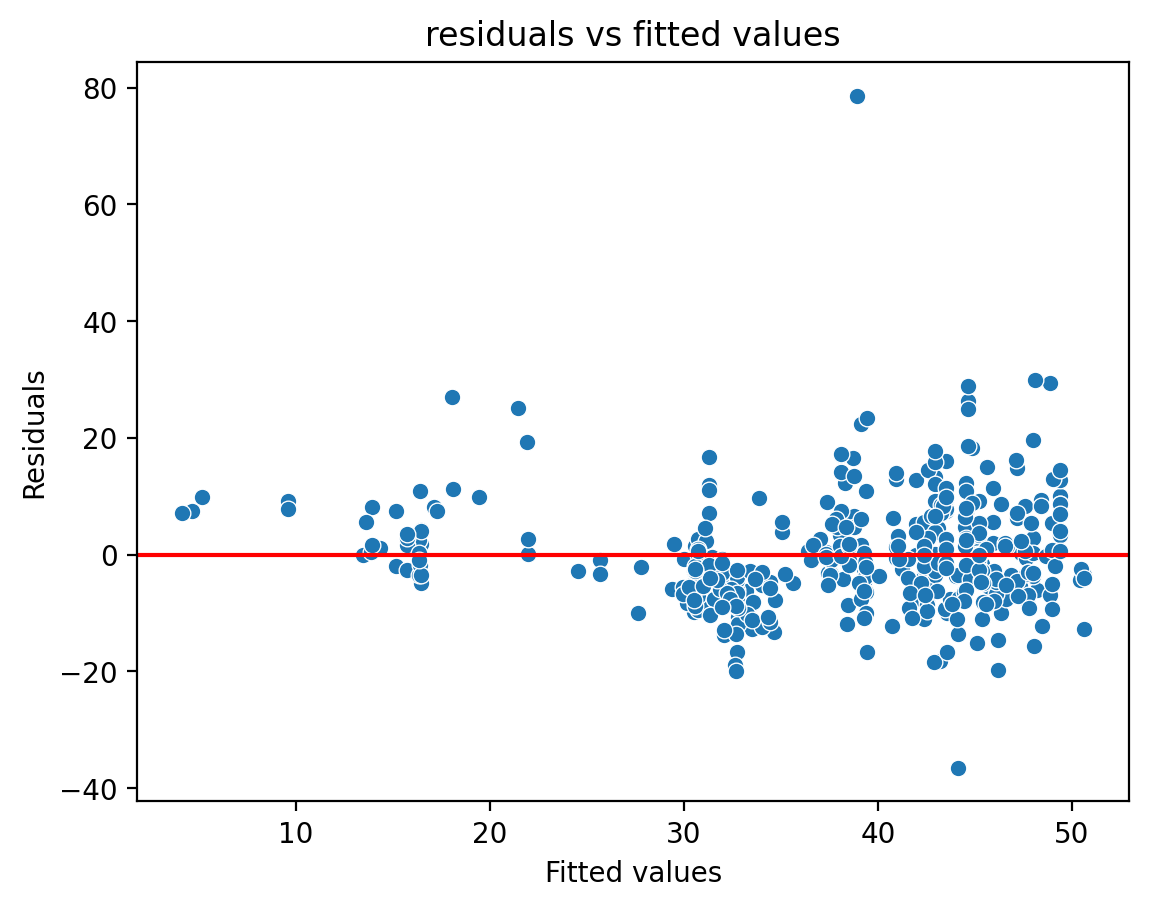

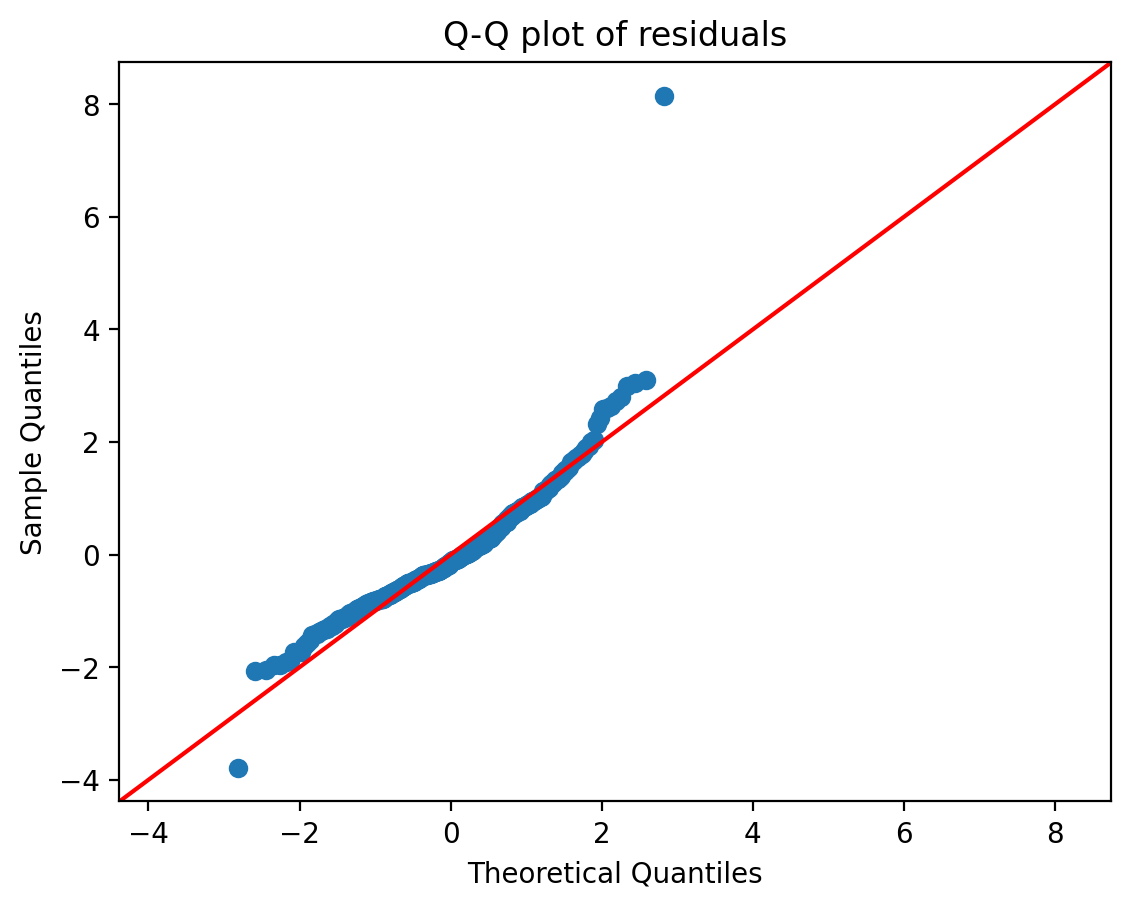

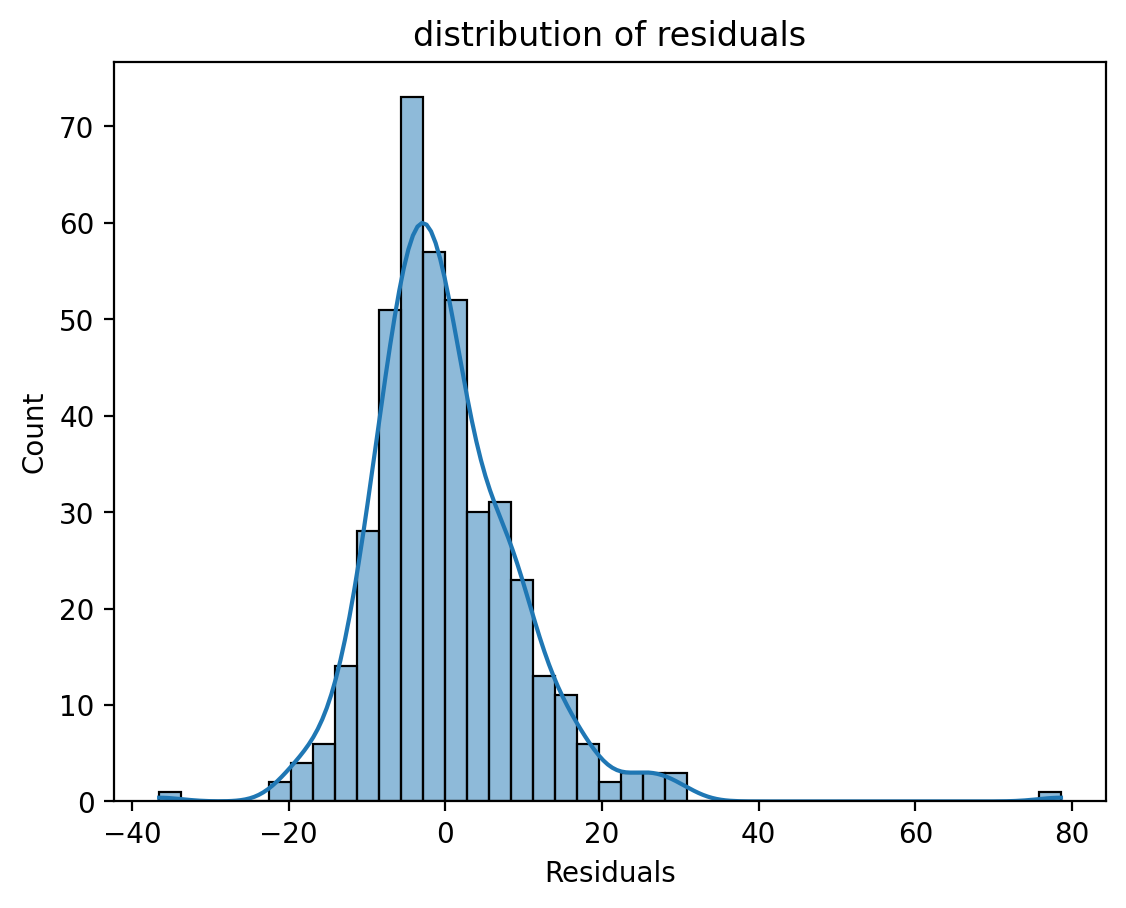

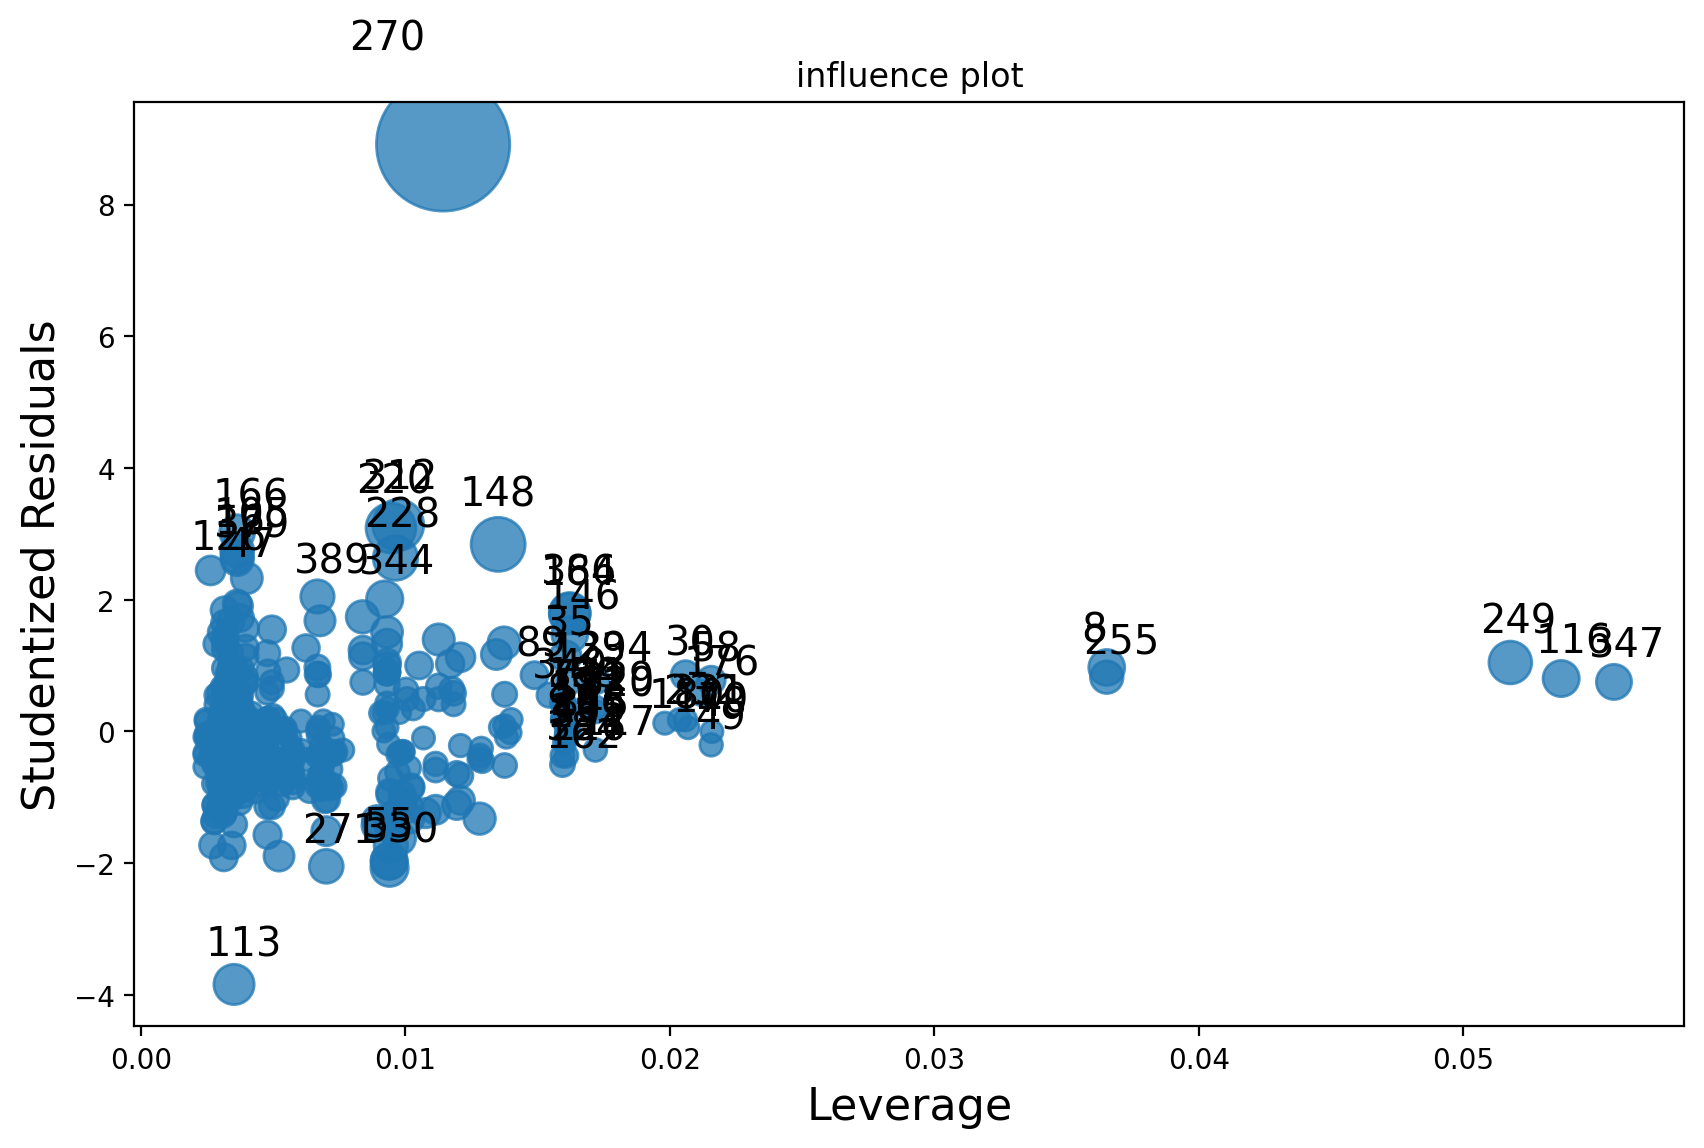

In [ ]:
# the best model is model_forward

fitted_values = model_forward.fittedvalues
residuals = model_forward.resid

# residuals vs fitted values
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('residuals vs fitted values')
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q plot of residuals')
plt.show()

# histogram of residuals
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('distribution of residuals')
plt.show()

# influence plot
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.influence_plot(model_forward, ax=ax, criterion="cooks")
plt.title('influence plot')
plt.show()

Finally, we can check the Out-of-sample Prediction or test error (MSPE):

In [ ]:
X_test = test[features_forward].copy()
X_test = X_test.fillna(0)
X_test = sm.add_constant(X_test)

# True values
y_test = test['price_twd_msq']

# Predict using the best model (e.g., forward selection)
y_pred = model_forward.predict(X_test)

# Calculate MSPE (Mean Squared Prediction Error)
mspe = np.mean((y_test - y_pred) ** 2)
print(f"Test MSPE (out-of-sample): {mspe:.2f}")

# my addition; square root of the error:
print(np.sqrt(mspe))

Test MSPE (out-of-sample): 64.80
8.049983519171274


The MSPE of 64.80 is on par with earlier error predictions of RMSE = ~8; the errors are still noticable as 8 thousand taiwanese dollars per square meter is quite a big margin of error.

## Cross Validation

In Python, for cross-validation of regression models is usually done with cross_val_score from sklearn.model_selection.

To get the raw cross-validation estimate of prediction error (e.g., mean squared error), use:

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = df_estate[['dist_to_mrt_m', 'house_age_0_15', 'house_age_30_45']]
y = df_estate['price_twd_msq']

model = LinearRegression()

# 5-fold cross-validation, scoring negative MSE (so we multiply by -1 to get positive MSE)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

# Raw cross-validation estimate of prediction error (mean MSE)
cv_mse = -cv_scores.mean()
cv_rmse = np.sqrt(cv_mse)

print(f"Cross-validated MSE: {cv_mse:.2f}")
print(f"Cross-validated RMSE: {cv_rmse:.2f}")

Cross-validated MSE: 95.90
Cross-validated RMSE: 9.79


# Summary

1. Do you understand all numerical measures printed in the SUMMARY of the regression report?
2. Why do we need a cross-validation?
3. What are the diagnostic plots telling us?
4. How to compare similar, but competing models?
5. What is VIF telling us?
6. How to choose best set of predictors for the model?



 I do understand what the most important measures like p-value, R-squared, AIC, Durbin-Watson mean. For the rest of them I'm looking them up on the fly :)

 We need cross-validation to check how well the model works on new data, not only on the data used to estimate it. It helps to avoid overfitting.

 Diagnostic plots show whether the regression assumptions are reasonable. They help check residual patterns, normality of residuals and possible influential observations.

 Similar models can be compared using measures such as AIC, RSE, RMSE, MSPE, or cross-validation error. Usually, the better model has lower prediction error and importantly, lower AIC.

 VIF tells us whether predictors are strongly correlated with each other. If VIF is high, multicollinearity may be a problem. In our case, VIF values were low, so it was not an issue.

 The best set of predictors can be chosen by looking at p-values, model fit, prediction error, AIC, and also by using methods such as forward or backward selection. We should also naturally think about it the variables make sense in the real world and theory.